In [1]:
## 셀 1: 데이터 불러오기

import pandas as pd

# 기존 지표선정 결과(v2, IDW_mean 포함)
df_v2 = pd.read_csv('grid_HSI_selected_indicators_v2.csv')
print("df_v2:", df_v2.shape)

# 기상 데이터(풍속, 상대습도)
weather = pd.read_csv('격자30m_2024_월별_기상_통합.csv')
print("weather:", weather.shape)

# 시간대별 원본(work_XXh, visi_XXh) 다시 필요 -> 09번 merge 결과에서 가져옴
df_hourly = pd.read_csv('grid_HSI_final_merged.csv', usecols=['grid_id'] +
    [f'work_{h:02d}h' for h in range(24)] + [f'visi_{h:02d}h' for h in range(24)])
print("df_hourly:", df_hourly.shape)

df_v2: (11388, 23)
weather: (54029, 22)
df_hourly: (11388, 49)


In [2]:
## 셀 2: 풍속·상대습도 평균 계산

windspeed_cols = [c for c in weather.columns if c.startswith('windspeed_')]
rh_cols = [c for c in weather.columns if c.startswith('rh_')]

weather['windspeed_mean'] = weather[windspeed_cols].mean(axis=1, skipna=True)
weather['rh_mean'] = weather[rh_cols].mean(axis=1, skipna=True)

weather['grid_id'] = weather['grid_id'].astype('Int64')  # 실수형 -> 정수형 통일

weather_selected = weather[['grid_id', 'windspeed_mean', 'rh_mean']]

print(weather_selected.describe())
print("\n결측치:")
print(weather_selected.isna().sum())

            grid_id  windspeed_mean       rh_mean
count       54029.0    53987.000000  53987.000000
mean        27015.0        1.096688     72.122183
std    15596.973184        0.174502      1.001181
min             1.0        0.444000     69.408000
25%         13508.0        1.041667     72.077000
50%         27015.0        1.125667     72.313500
75%         40522.0        1.224667     72.482750
max         54029.0        1.388667     74.168500

결측치:
grid_id            0
windspeed_mean    42
rh_mean           42
dtype: int64


In [3]:
## 셀 3: 방문인구(pop_peak_h)·직장인구(pop_lunch_) 11~17시로 재계산

visi_1117 = [f'visi_{h:02d}h' for h in range(11, 18)]  # 11~17시
work_1117 = [f'work_{h:02d}h' for h in range(11, 18)]

df_hourly['pop_peak_h_v2'] = df_hourly[visi_1117].mean(axis=1)
df_hourly['pop_lunch_v2'] = df_hourly[work_1117].mean(axis=1)

print("재계산 완료")
print(df_hourly[['pop_peak_h_v2', 'pop_lunch_v2']].describe())

재계산 완료
       pop_peak_h_v2  pop_lunch_v2
count   11388.000000  11388.000000
mean        0.435385      0.288325
std         1.120410      0.827065
min         0.000000      0.000000
25%         0.042733      0.012617
50%         0.115424      0.038192
75%         0.300150      0.126974
max        18.704650     12.003039


In [4]:
## 셀 4: 전체 데이터 merge + pop_peak_h, pop_lunch_ 교체

df_v3 = df_v2.merge(weather_selected, on='grid_id', how='left')
df_v3 = df_v3.merge(df_hourly[['grid_id', 'pop_peak_h_v2', 'pop_lunch_v2']], on='grid_id', how='left')

# 기존 pop_peak_h, pop_lunch_ 컬럼 삭제하고 새 버전으로 교체
df_v3 = df_v3.drop(columns=['pop_peak_h', 'pop_lunch_'])
df_v3 = df_v3.rename(columns={'pop_peak_h_v2': 'pop_peak_h', 'pop_lunch_v2': 'pop_lunch_'})

print("df_v3 최종 shape:", df_v3.shape)
print(df_v3.columns.tolist())

df_v3 최종 shape: (11388, 25)
['grid_id', 'geometry', 'ADM_SIDO', 'ADM_SGG_CD', 'ADM_EMD_CD', 'ADM_EMD_NM', 'lon', 'lat', 'pop_elderl', 'park_cnt', 'shade_cnt', 'cooling_shelter_cnt', 'daycare_cnt', 'smart_shelter_cnt', 'tree_road_len', 'NDVI_mean_5scene', 'LST_C_mean_5scene', 'LC1_100_시가화건조지역_ratio', 'GREEN_ratio_LC', 'senior_facility_total', 'IDW_mean', 'windspeed_mean', 'rh_mean', 'pop_peak_h', 'pop_lunch_']


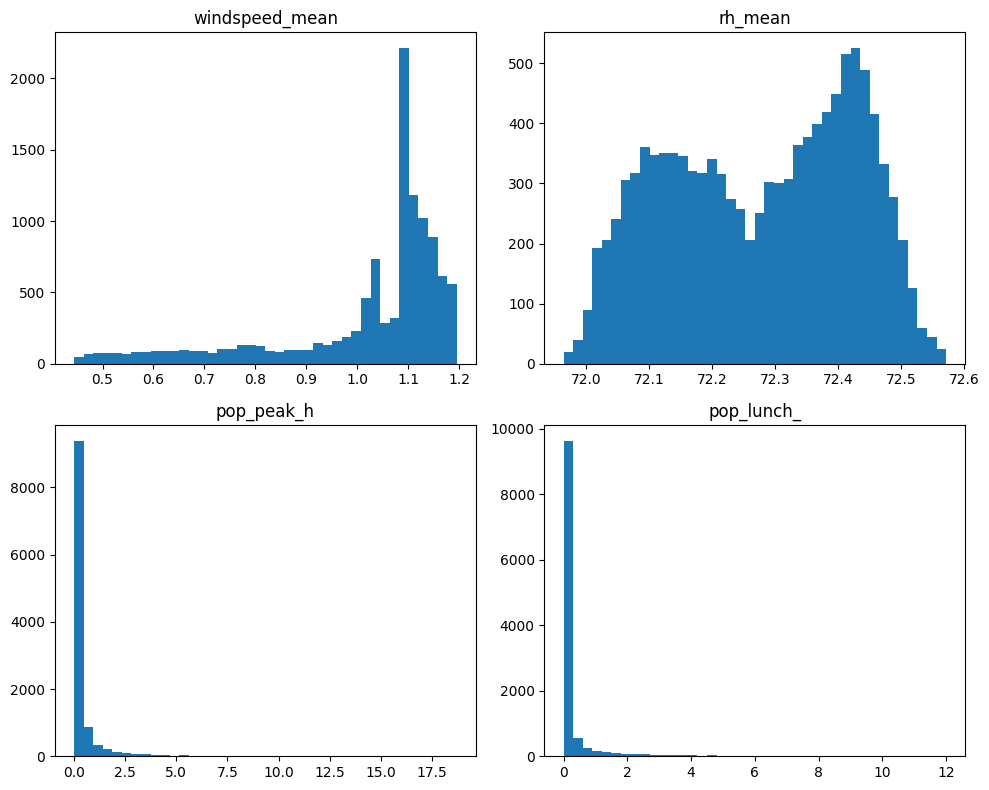

In [5]:
## 셀 5: 신규/재계산 지표 히스토그램

import matplotlib.pyplot as plt

check_cols = ['windspeed_mean', 'rh_mean', 'pop_peak_h', 'pop_lunch_']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(check_cols):
    axes[i].hist(df_v3[col].dropna(), bins=40)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [6]:
## 셀 6: 전체 표준화 (E/S/A 축)

import numpy as np
import pandas as pd

def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

def minmax_eps(s, eps=0.01):
    m = minmax(s)
    return m * (1 - eps) + eps

def log_minmax(s):
    return minmax(np.log1p(s))

df_v3['adaptive_facility_total'] = (
    df_v3['park_cnt'] + df_v3['shade_cnt'] +
    df_v3['cooling_shelter_cnt'] + df_v3['smart_shelter_cnt']
)

# ── E축 (4개: LST, IDW_mean, windspeed_mean, rh_mean) ──
e_std = pd.DataFrame(index=df_v3.index)
e_std['LST_C_mean_5scene'] = minmax(df_v3['LST_C_mean_5scene'])
e_std['IDW_mean'] = minmax(df_v3['IDW_mean'])
e_std['windspeed_mean'] = minmax(df_v3['windspeed_mean'])
e_std['rh_mean'] = minmax(df_v3['rh_mean'])

# 결측치(풍속/습도 42개, LST 433개) 각 컬럼 평균으로 대체
for col in e_std.columns:
    e_std[col] = e_std[col].fillna(e_std[col].mean())

# ── S축 (LC1_100, pop_peak_h, pop_elderl, pop_lunch_, daycare_cnt, senior_facility_total) ──
s_std = pd.DataFrame(index=df_v3.index)
s_std['LC1_100_시가화건조지역_ratio'] = minmax(df_v3['LC1_100_시가화건조지역_ratio'])
for col in ['pop_peak_h', 'pop_elderl', 'pop_lunch_', 'daycare_cnt', 'senior_facility_total']:
    s_std[col] = log_minmax(df_v3[col])

# ── A축 (NDVI, GREEN_ratio_LC, adaptive_facility_total, tree_road_len) ──
a_std = pd.DataFrame(index=df_v3.index)
a_std['NDVI_mean_5scene'] = minmax(df_v3['NDVI_mean_5scene'])
a_std['GREEN_ratio_LC'] = minmax(df_v3['GREEN_ratio_LC'])
for col in ['adaptive_facility_total', 'tree_road_len']:
    a_std[col] = log_minmax(df_v3[col])

EPS = 0.01
a_std = a_std.clip(lower=EPS)

print("=== E축 표준화 결과 ===")
print(e_std.describe())
print("\n=== S축 표준화 결과 ===")
print(s_std.describe())
print("\n=== A축 표준화 결과 ===")
print(a_std.describe())

print("\n결측치 확인 (E/S/A):", e_std.isna().sum().sum(), s_std.isna().sum().sum(), a_std.isna().sum().sum())

=== E축 표준화 결과 ===
       LST_C_mean_5scene      IDW_mean  windspeed_mean       rh_mean
count       11388.000000  11388.000000    11388.000000  11388.000000
mean            0.335521      0.544321        0.760722      0.517497
std             0.108548      0.222317        0.234022      0.243022
min             0.000000      0.000000        0.000000      0.000000
25%             0.283819      0.406124        0.720830      0.301731
50%             0.342794      0.523310        0.867347      0.544518
75%             0.406561      0.709466        0.905501      0.733718
max             1.000000      1.000000        1.000000      1.000000

=== S축 표준화 결과 ===
       LC1_100_시가화건조지역_ratio    pop_peak_h    pop_elderl    pop_lunch_  \
count           11388.000000  11388.000000  11388.000000  11388.000000   
mean                0.577869      0.083566      0.347572      0.065173   
std                 0.360192      0.128610      0.180903      0.132846   
min                 0.000000      0.000000    

In [7]:
## 셀 6-저장: 표준화 결과 저장

meta_cols = ['grid_id', 'geometry', 'ADM_SIDO', 'ADM_SGG_CD', 'ADM_EMD_CD', 'ADM_EMD_NM', 'lon', 'lat']
meta_keep = df_v3[meta_cols]

df_standardized_v3 = pd.concat([meta_keep, e_std, s_std, a_std], axis=1)

df_standardized_v3.to_csv('grid_HSI_standardized_v3.csv', index=False, encoding='utf-8-sig')

print("저장 완료: grid_HSI_standardized_v3.csv")
print(f"행 수: {len(df_standardized_v3):,}개, 컬럼 수: {len(df_standardized_v3.columns)}개")
print()
print("E축:", e_std.columns.tolist())
print("S축:", s_std.columns.tolist())
print("A축:", a_std.columns.tolist())

저장 완료: grid_HSI_standardized_v3.csv
행 수: 11,388개, 컬럼 수: 22개

E축: ['LST_C_mean_5scene', 'IDW_mean', 'windspeed_mean', 'rh_mean']
S축: ['LC1_100_시가화건조지역_ratio', 'pop_peak_h', 'pop_elderl', 'pop_lunch_', 'daycare_cnt', 'senior_facility_total']
A축: ['NDVI_mean_5scene', 'GREEN_ratio_LC', 'adaptive_facility_total', 'tree_road_len']


In [8]:
## 셀 7: E/S/A 축별 PCA (부호보정 포함)

from sklearn.decomposition import PCA

def run_axis_pca(std_df, axis_name):
    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(std_df.fillna(0)).flatten()

    loadings = pca.components_[0]
    print(f"\n[{axis_name}] PC1 설명분산비: {pca.explained_variance_ratio_[0]:.3f}")
    print(f"[{axis_name}] 적재값(loading):")
    for col, load in zip(std_df.columns, loadings):
        print(f"  {col}: {load:.3f}")

    if loadings.mean() < 0:
        pc1 = -pc1
        print(f"[{axis_name}] 부호 반전 적용됨")

    pc1_series = pd.Series(pc1, index=std_df.index)
    score = minmax_eps(pc1_series)
    return score, pca.explained_variance_ratio_[0]

e_score, e_var = run_axis_pca(e_std, 'E축')
s_score, s_var = run_axis_pca(s_std, 'S축')
a_score, a_var = run_axis_pca(a_std, 'A축')

print("\n=== 축 스코어 요약 ===")
print("E_score:", e_score.describe())
print("\nS_score:", s_score.describe())
print("\nA_score:", a_score.describe())


[E축] PC1 설명분산비: 0.659
[E축] 적재값(loading):
  LST_C_mean_5scene: 0.049
  IDW_mean: -0.565
  windspeed_mean: -0.636
  rh_mean: -0.524
[E축] 부호 반전 적용됨

[S축] PC1 설명분산비: 0.714
[S축] 적재값(loading):
  LC1_100_시가화건조지역_ratio: 0.919
  pop_peak_h: 0.189
  pop_elderl: 0.300
  pop_lunch_: 0.171
  daycare_cnt: 0.003
  senior_facility_total: 0.005

[A축] PC1 설명분산비: 0.663
[A축] 적재값(loading):
  NDVI_mean_5scene: 0.425
  GREEN_ratio_LC: 0.893
  adaptive_facility_total: -0.017
  tree_road_len: -0.147

=== 축 스코어 요약 ===
E_score: count    11388.000000
mean         0.691565
std          0.237449
min          0.010000
25%          0.497371
50%          0.798196
75%          0.875653
max          1.000000
dtype: float64

S_score: count    11388.000000
mean         0.430791
std          0.242906
min          0.010000
25%          0.226915
50%          0.463816
75%          0.634546
max          1.000000
dtype: float64

A_score: count    11388.000000
mean         0.451148
std          0.284012
min          0.010000
25

In [9]:
## 셀 8-보고서용: E축 지표 변별력 비교표 (원본 단위 기준)

import pandas as pd

comparison = pd.DataFrame({
    '지표': ['LST(지표면온도, ℃)', 'IDW_mean(기온, ℃)', 'windspeed_mean(풍속, m/s)', 'rh_mean(습도, %)'],
    '최솟값': [
        df_v3['LST_C_mean_5scene'].min(),
        df_v3['IDW_mean'].min(),
        df_v3['windspeed_mean'].min(),
        df_v3['rh_mean'].min(),
    ],
    '최댓값': [
        df_v3['LST_C_mean_5scene'].max(),
        df_v3['IDW_mean'].max(),
        df_v3['windspeed_mean'].max(),
        df_v3['rh_mean'].max(),
    ],
    '평균': [
        df_v3['LST_C_mean_5scene'].mean(),
        df_v3['IDW_mean'].mean(),
        df_v3['windspeed_mean'].mean(),
        df_v3['rh_mean'].mean(),
    ],
    '표준편차': [
        df_v3['LST_C_mean_5scene'].std(),
        df_v3['IDW_mean'].std(),
        df_v3['windspeed_mean'].std(),
        df_v3['rh_mean'].std(),
    ],
})

comparison['값범위(최댓값-최솟값)'] = comparison['최댓값'] - comparison['최솟값']
comparison['변동계수(%, 표준편차/평균)'] = (comparison['표준편차'] / comparison['평균'] * 100)

comparison = comparison.round(3)
print(comparison.to_string(index=False))

                     지표    최솟값    최댓값     평균  표준편차  값범위(최댓값-최솟값)  변동계수(%, 표준편차/평균)
          LST(지표면온도, ℃) 28.510 55.640 37.613 3.003        27.130             7.983
        IDW_mean(기온, ℃) 29.144 30.580 29.925 0.319         1.436             1.066
windspeed_mean(풍속, m/s)  0.444  1.195  1.016 0.176         0.751            17.318
         rh_mean(습도, %) 71.964 72.571 72.278 0.147         0.606             0.204


In [10]:
## 셀 8: 엔트로피 가중치 계산

import numpy as np
import pandas as pd

axis_df = pd.DataFrame({
    'E': e_score,
    'S': s_score,
    'A': a_score
})

n = len(axis_df)
k = 1 / np.log(n)

p = axis_df / axis_df.sum(axis=0)

def safe_plogp(p_col):
    return np.where(p_col == 0, 0, p_col * np.log(p_col))

entropy = -k * p.apply(safe_plogp).sum(axis=0)
diversity = 1 - entropy
weights = diversity / diversity.sum()

print("=== 엔트로피 계산 결과 ===")
print("엔트로피 (e_j):")
print(entropy)
print("\n다양성 (d_j = 1-e_j):")
print(diversity)
print("\n=== 최종 가중치 ===")
print(weights)

=== 엔트로피 계산 결과 ===
엔트로피 (e_j):
E    0.992447
S    0.979076
A    0.979019
dtype: float64

다양성 (d_j = 1-e_j):
E    0.007553
S    0.020924
A    0.020981
dtype: float64

=== 최종 가중치 ===
E    0.152721
S    0.423064
A    0.424215
dtype: float64


In [11]:
## 셀 7-실험: E축 서브그룹 분리 (LST vs 관측소기상)

# 1. LST 서브그룹 (단독, PCA 불필요)
lst_score = e_std['LST_C_mean_5scene']

# 2. 관측소기상 서브그룹 (IDW_mean, windspeed_mean, rh_mean -> PCA)
weather_std = e_std[['IDW_mean', 'windspeed_mean', 'rh_mean']]
weather_score, weather_var = run_axis_pca(weather_std, '관측소기상 서브그룹')

# 3. 두 서브그룹(LST vs 관측소기상)을 엔트로피로 재결합
sub_df = pd.DataFrame({'LST': lst_score, '기상': weather_score})

n = len(sub_df)
k = 1 / np.log(n)
p_sub = sub_df / sub_df.sum(axis=0)
entropy_sub = -k * p_sub.apply(safe_plogp).sum(axis=0)
diversity_sub = 1 - entropy_sub
weights_sub = diversity_sub / diversity_sub.sum()

print("\n=== E축 서브그룹 엔트로피 가중치 ===")
print(weights_sub)

# 최종 E_score (서브그룹 가중합)
e_score_v2 = weights_sub['LST'] * lst_score + weights_sub['기상'] * weather_score
e_score_v2 = minmax_eps(e_score_v2)

print("\n=== E_score(서브그룹 방식) 요약 ===")
print(e_score_v2.describe())

print("\n=== 기존 E_score(4개 통합 PCA) vs 신규 E_score(서브그룹) 비교 ===")
print(pd.DataFrame({'기존(4개통합PCA)': e_score, '신규(서브그룹)': e_score_v2}).corr())


[관측소기상 서브그룹] PC1 설명분산비: 0.705
[관측소기상 서브그룹] 적재값(loading):
  IDW_mean: -0.566
  windspeed_mean: -0.636
  rh_mean: -0.524
[관측소기상 서브그룹] 부호 반전 적용됨

=== E축 서브그룹 엔트로피 가중치 ===
LST    0.459456
기상     0.540544
dtype: float64

=== E_score(서브그룹 방식) 요약 ===
count    11388.000000
mean         0.538137
std          0.172612
min          0.010000
25%          0.406965
50%          0.586010
75%          0.675554
max          1.000000
dtype: float64

=== 기존 E_score(4개 통합 PCA) vs 신규 E_score(서브그룹) 비교 ===
             기존(4개통합PCA)  신규(서브그룹)
기존(4개통합PCA)     1.000000  0.920853
신규(서브그룹)        0.920853  1.000000


/opt/app-root/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [12]:
## 셀 8-재계산: E_score(서브그룹 방식) 확정 후 전체 엔트로피 가중치 재계산

# E_score 최종 확정 (서브그룹 방식)
e_score = e_score_v2

axis_df = pd.DataFrame({
    'E': e_score,
    'S': s_score,
    'A': a_score
})

n = len(axis_df)
k = 1 / np.log(n)

p = axis_df / axis_df.sum(axis=0)
entropy = -k * p.apply(safe_plogp).sum(axis=0)
diversity = 1 - entropy
weights = diversity / diversity.sum()

print("=== 최종 엔트로피 계산 결과 (E축 서브그룹 방식 반영) ===")
print("엔트로피 (e_j):")
print(entropy)
print("\n다양성 (d_j = 1-e_j):")
print(diversity)
print("\n=== 최종 가중치 ===")
print(weights)

=== 최종 엔트로피 계산 결과 (E축 서브그룹 방식 반영) ===
엔트로피 (e_j):
E    0.993795
S    0.979076
A    0.979019
dtype: float64

다양성 (d_j = 1-e_j):
E    0.006205
S    0.020924
A    0.020981
dtype: float64

=== 최종 가중치 ===
E    0.128974
S    0.434921
A    0.436105
dtype: float64


In [13]:
## 셀 9: HSI 계산 (덧셈식) + 재정규화

wE, wS, wA = weights['E'], weights['S'], weights['A']

HSI_raw = wE * e_score + wS * s_score - wA * a_score

print("=== HSI_raw (재정규화 전) ===")
print(HSI_raw.describe())

HSI = (HSI_raw - HSI_raw.min()) / (HSI_raw.max() - HSI_raw.min())

print("\n=== HSI (0~1 재정규화 후) ===")
print(HSI.describe())

=== HSI_raw (재정규화 전) ===
count    11388.000000
mean         0.060018
std          0.228202
min         -0.404803
25%         -0.089906
50%          0.096642
75%          0.251847
max          0.494582
dtype: float64

=== HSI (0~1 재정규화 후) ===
count    11388.000000
mean         0.516822
std          0.253731
min          0.000000
25%          0.350125
50%          0.557542
75%          0.730111
max          1.000000
dtype: float64


In [14]:
## 셀 10: Jenks 자연구간법 5등급 분류 (KMeans 근사)

from sklearn.cluster import KMeans
import numpy as np

X = HSI.values.reshape(-1, 1)
km = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = km.fit_predict(X)

centers = km.cluster_centers_.flatten()
order = np.argsort(centers)
label_map = {old: new+1 for new, old in enumerate(order)}
HSI_grade = pd.Series(labels, index=HSI.index).map(label_map)

print("=== 등급별 격자 개수 ===")
print(HSI_grade.value_counts().sort_index())

print("\n=== 등급별 비율(%) ===")
print((HSI_grade.value_counts(normalize=True).sort_index() * 100).round(2))

print("\n=== 등급별 HSI 범위 ===")
for g in sorted(HSI_grade.unique()):
    vals = HSI[HSI_grade == g]
    print(f"{g}등급: {vals.min():.4f} ~ {vals.max():.4f}")

# 쏠림 체크 (5% 미만 또는 40% 이상)
ratio = HSI_grade.value_counts(normalize=True)
print("\n쏠림 여부(5%~40% 벗어난 등급 있는지):", ((ratio < 0.05) | (ratio > 0.40)).any())

=== 등급별 격자 개수 ===
1    1829
2    1569
3    2491
4    2534
5    2965
Name: count, dtype: int64

=== 등급별 비율(%) ===
1    16.06
2    13.78
3    21.87
4    22.25
5    26.04
Name: proportion, dtype: float64

=== 등급별 HSI 범위 ===
1등급: 0.0000 ~ 0.1961
2등급: 0.1967 ~ 0.4052
3등급: 0.4053 ~ 0.5698
4등급: 0.5699 ~ 0.7239
5등급: 0.7241 ~ 1.0000

쏠림 여부(5%~40% 벗어난 등급 있는지): False


In [15]:
## 셀 11: 최종 HSI 결과 저장

meta_cols = ['grid_id', 'geometry', 'ADM_SIDO', 'ADM_SGG_CD', 'ADM_EMD_CD', 'ADM_EMD_NM', 'lon', 'lat']
meta_keep_v3 = df_v3[meta_cols]

df_hsi_final_v3 = meta_keep_v3.copy()
df_hsi_final_v3['E_score'] = e_score
df_hsi_final_v3['S_score'] = s_score
df_hsi_final_v3['A_score'] = a_score
df_hsi_final_v3['HSI'] = HSI
df_hsi_final_v3['HSI_grade'] = HSI_grade

df_hsi_final_v3.to_csv('grid_HSI_final_result_v3.csv', index=False, encoding='utf-8-sig')

print("저장 완료: grid_HSI_final_result_v3.csv")
print(f"행 수: {len(df_hsi_final_v3):,}개, 컬럼 수: {len(df_hsi_final_v3.columns)}개")
print(df_hsi_final_v3.columns.tolist())

저장 완료: grid_HSI_final_result_v3.csv
행 수: 11,388개, 컬럼 수: 13개
['grid_id', 'geometry', 'ADM_SIDO', 'ADM_SGG_CD', 'ADM_EMD_CD', 'ADM_EMD_NM', 'lon', 'lat', 'E_score', 'S_score', 'A_score', 'HSI', 'HSI_grade']


In [16]:
print("S_score 상위 50% 비율:", (s_score > 0.5).mean())
print("A_score 하위 50% 비율:", (a_score < 0.5).mean())

S_score 상위 50% 비율: 0.4473129610115911
A_score 하위 50% 비율: 0.6316297857393748


In [17]:
print("GREEN_ratio_LC 원본값 중앙값:", df_v3['GREEN_ratio_LC'].median())
print("GREEN_ratio_LC 원본값 평균:", df_v3['GREEN_ratio_LC'].mean())
print("GREEN_ratio_LC < 0.1인 격자 비율:", (df_v3['GREEN_ratio_LC'] < 0.1).mean())

GREEN_ratio_LC 원본값 중앙값: 0.27715
GREEN_ratio_LC 원본값 평균: 0.3640185458377239
GREEN_ratio_LC < 0.1인 격자 비율: 0.31972251492799436


/tmp/ipykernel_62/2978551900.py:10: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_62/2978551900.py:10: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_62/2978551900.py:10: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_62/2978551900.py:10: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_62/2978551900.py:10: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_62/2978551900.py:10: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from current font.
  plt.tight_layout()
/opt/app-root/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from current font.
  fig.canvas.print_figure(bytes_io, *

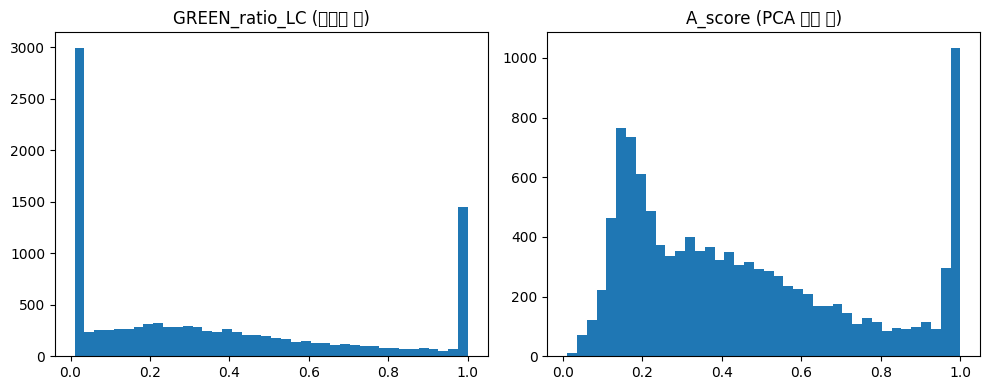

A_score 중앙값: 0.3832525209140789
A_score 평균: 0.45114778528185595


In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(a_std['GREEN_ratio_LC'], bins=40)
axes[0].set_title('GREEN_ratio_LC (표준화 후)')

axes[1].hist(a_score, bins=40)
axes[1].set_title('A_score (PCA 결합 후)')

plt.tight_layout()
plt.show()

print("A_score 중앙값:", a_score.median())
print("A_score 평균:", a_score.mean())